# Will they stay in Our Bank or choose an other one? Deep Learning Approach

- Author: Mian Abdul Basit 
- linkedln: 
- Github: https://github.com/mianabdulbasit-tech/Data-Science-And-AI

# AIM:
- `we will classify the customers who will stay in our bank or leave the bank using deep learning approach.`

# Binary Classification with Bank Churn Dataset

`Data Descrition:`



In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the datasets
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

In [3]:
# Train dataset and exploration

df_train.head().T

,0,1,2,3,4
id,0,1,2,3,4
CustomerId,15674932,15749177,15694510,15741417,15766172
Surname,Okwudilichukwu,Okwudiliolisa,Hsueh,Kao,Chiemenam
CreditScore,668,627,678,581,716
Geography,France,France,France,France,Spain
Gender,Male,Male,Male,Male,Male
Age,33.0,33.0,40.0,34.0,33.0
Tenure,3,1,10,2,5
Balance,0.0,0.0,0.0,148882.54,0.0
NumOfProducts,2,2,2,1,2


In [4]:
df = df_train.copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [6]:
# find the null values
df.isnull().sum().sort_values(ascending=False)

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,165034.0,8.251650e+04,47641.356500,0.00,41258.25,82516.5,1.237748e+05,165033.00
CustomerId,165034.0,1.569201e+07,71397.816791,15565701.00,15633141.00,15690169.0,1.575682e+07,15815690.00
CreditScore,165034.0,6.564544e+02,80.103340,350.00,597.00,659.0,7.100000e+02,850.00
Age,165034.0,3.812589e+01,8.867205,18.00,32.00,37.0,4.200000e+01,92.00
Tenure,165034.0,5.020353e+00,2.806159,0.00,3.00,5.0,7.000000e+00,10.00
Balance,165034.0,5.547809e+04,62817.663278,0.00,0.00,0.0,1.199395e+05,250898.09
NumOfProducts,165034.0,1.554455e+00,0.547154,1.00,1.00,2.0,2.000000e+00,4.00
HasCrCard,165034.0,7.539537e-01,0.430707,0.00,1.00,1.0,1.000000e+00,1.00
IsActiveMember,165034.0,4.977702e-01,0.499997,0.00,0.00,0.0,1.000000e+00,1.00
EstimatedSalary,165034.0,1.125748e+05,50292.865585,11.58,74637.57,117948.0,1.551525e+05,199992.48


In [8]:
df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [9]:
cat_cols = ['Geography', 'Gender', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']

num_cols = ['CreditScore',  'Age', 'Balance', 'EstimatedSalary']

# find the value count of the categorical columns
for col in cat_cols:
    print(df[col].value_counts())
    print()

Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64

Gender
Male      93150
Female    71884
Name: count, dtype: int64

Tenure
2     18045
7     17810
4     17554
8     17520
5     17268
1     16760
9     16709
3     16630
6     15822
10     5909
0      5007
Name: count, dtype: int64

NumOfProducts
2    84291
1    77374
3     2894
4      475
Name: count, dtype: int64

HasCrCard
1.0    124428
0.0     40606
Name: count, dtype: int64

IsActiveMember
0.0    82885
1.0    82149
Name: count, dtype: int64

Exited
0    130113
1     34921
Name: count, dtype: int64



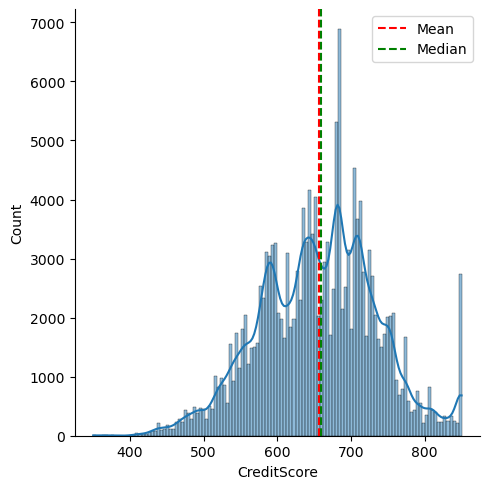

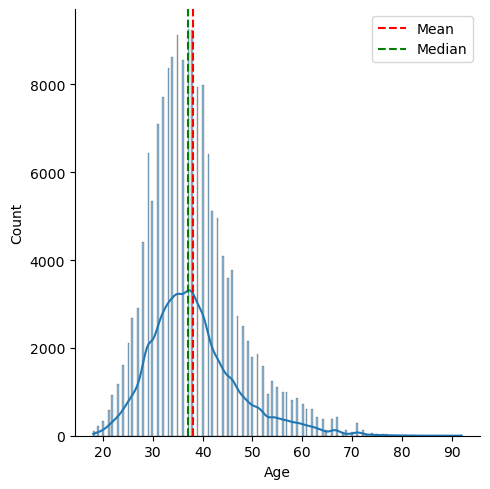

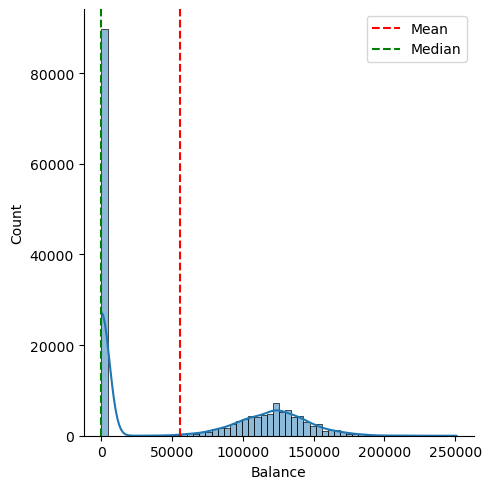

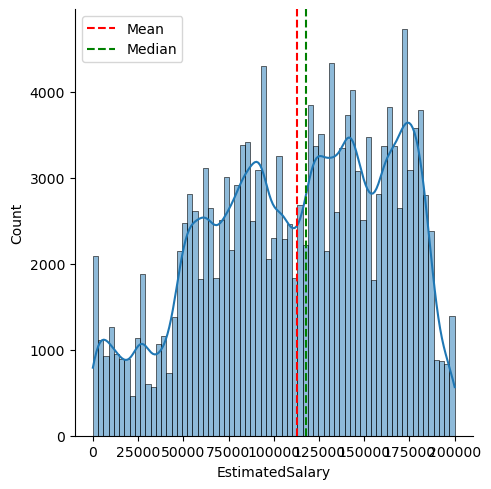

In [10]:
# create histogram of numerical columns using sns and kde=True

for col in num_cols:
    sns.displot(df[col], kde=True)
    plt.axvline(df[col].mean(), color='r', linestyle='--', label='Mean')
    plt.axvline(df[col].median(), color='g', linestyle='--', label='Median')
    plt.legend()
    plt.show()

In [11]:
# # create a count plot for each column
# for col in cat_cols:
#     sns.countplot(df, x = df[col])
#     plt.show()

In [12]:
# print the number of rows and columns

print(f'The train dataset has {df.shape[0]} rows and {df.shape[0]} columns')

The train dataset has 165034 rows and 165034 columns


In [13]:
# split the data into X and y
X = df.drop(['Exited', 'id', 'CustomerId', 'Surname'], axis=1)
y = df['Exited']

# encode the categorical columns having object datatype using labelEncoder
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
for col in cat_cols:
    if df[col].dtype == 'object' or df[col].dtype == 'categorical':
        X[col] = label_encoder.fit_transform(X[col])
    else:
        pass

X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,668,0,1,33.0,3,0.00,2,1.0,0.0,181449.97
1,627,0,1,33.0,1,0.00,2,1.0,1.0,49503.50
2,678,0,1,40.0,10,0.00,2,1.0,0.0,184866.69
3,581,0,1,34.0,2,148882.54,1,1.0,1.0,84560.88
4,716,2,1,33.0,5,0.00,2,1.0,1.0,15068.83


In [14]:
y.value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

In [15]:
# split the data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Neural Network Architecture

c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.6743 - loss: 50.3780 - val_accuracy: 0.6643 - val_loss: 5.1168
Epoch 2/5
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 39s 9ms/step - accuracy: 0.7618 - loss: 0.8896 - val_accuracy: 0.7892 - val_loss: 0.5150
Epoch 3/5
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 44s 11ms/step - accuracy: 0.7881 - loss: 0.5166 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 4/5
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 33s 8ms/step - accuracy: 0.7881 - loss: 0.5186 - val_accuracy: 0.7893 - val_loss: 0.5152
Epoch 5/5
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.7882 - loss: 0.5165 - val_accuracy: 0.7893 - val_loss: 0.5150


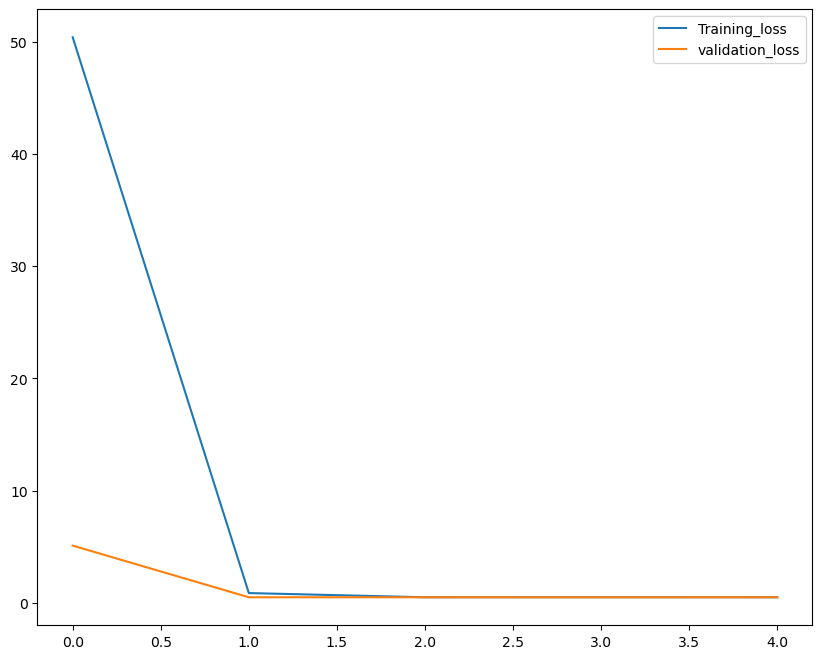

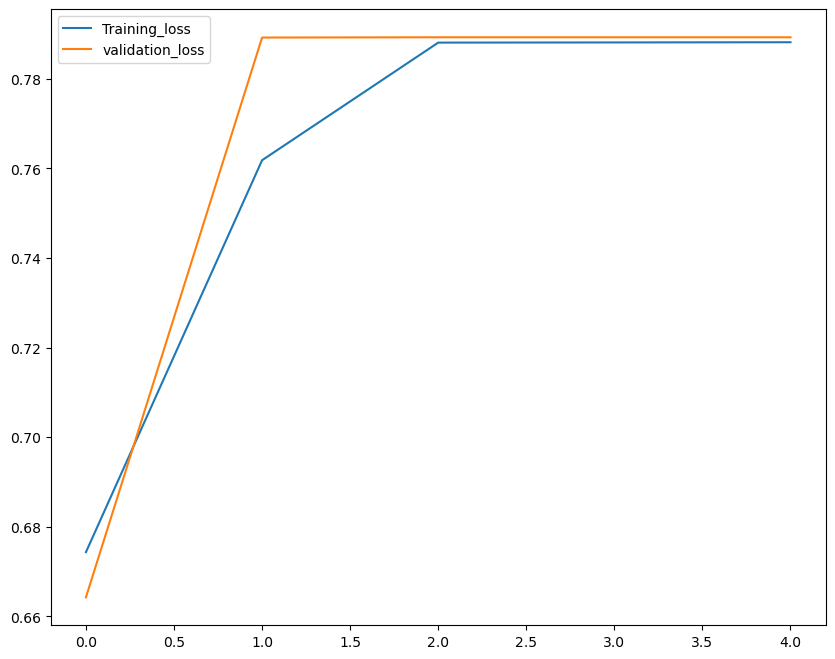

In [16]:
# create a deep neural network using tensorflow for binary classification
import tensorflow as tf 
from tensorflow.keras.callbacks import EarlyStopping


# builting the model
model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(128, activation='relu', 
                              input_shape=(X_train.shape[1],)), # input layer

        tf.keras.layers.Dense(64, activation='relu'), # hiden layers 1
        tf.keras.layers.Dense(32, activation='relu'), # hiden layers 2
        # tf.keras.layers.Dense(16, activation='relu'), # hiden layers 3
        # tf.keras.layers.Dense(8, activation='relu'), # hiden layers 4

        tf.keras.layers.Dense(1, activation='sigmoid') # output layer
])


#  Define the callback function
early_stopping = EarlyStopping(patience=15)

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train the model
history = model.fit(X_train, y_train, 
                    epochs=5, batch_size=32, verbose=1, 
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

# plot the training and testing loss and accuracy
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(history.history['loss'], label='Training_loss')
ax.plot(history.history['val_loss'], label='validation_loss')
plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(history.history['accuracy'], label='Training_loss')
ax.plot(history.history['val_accuracy'], label='validation_loss')
plt.legend()
plt.show()

# RandomForest Classifier Algorthim

Accuracy Score: 0.8591510891629048
Precision Score: 0.7192015209125475
Recall Score: 0.5439252336448598
F1 Score: 0.6194023741301679


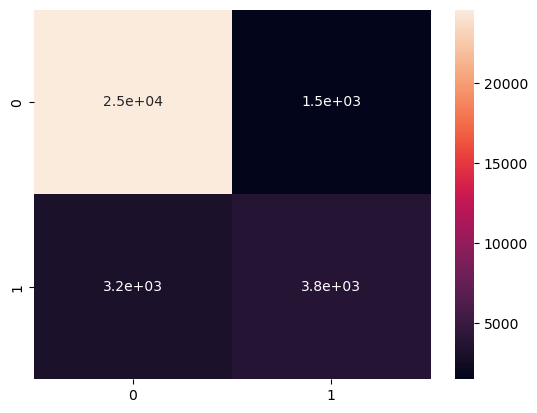

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Build a Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)

# predict the test data
y_pred = rf_model.predict(X_test)

print('Accuracy Score:', accuracy_score(y_test, y_pred))
print('Precision Score:', precision_score(y_test, y_pred))
print('Recall Score:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))

# plot the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

# convert categorical columns to numerical columns
le = LabelEncoder()
df_test['Geography'] = le.fit_transform(df_test['Geography'])
df_test['Gender'] = le.fit_transform(df_test['Gender'])
df_test['Surname'] = le.fit_transform(df_test['Surname'])

# predict the  test data and create a sumission file of probability of each class
y_pred = rf_model.predict_proba(df_test.drop(['id', 'CustomerId', 'Surname'], axis=1))
submission['Exited'] = y_pred[:, 1]
submission.to_csv('submission.csv', index=False)



# XGBoost Classifier

In [19]:
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# # Build a Random Forest model
# xgb = XGBClassifier()

# xgb.fit(X_train, y_train)

# # predict the test data
# y_pred = xgb.predict(X_test)

# print('Accuracy Score:', accuracy_score(y_test, y_pred))
# print('Precision Score:', precision_score(y_test, y_pred))
# print('Recall Score:', recall_score(y_test, y_pred))
# print('F1 Score:', f1_score(y_test, y_pred))

# # plot the confusion matrix
# from sklearn.metrics import confusion_matrix
# cm = confusion_matrix(y_test, y_pred)
# sns.heatmap(cm, annot=True)
# plt.show()

In [20]:
# # predict the  test data and create a sumission file of probability of each class
# from sklearn.preprocessing import LabelEncoder

# # convert categorical columns to numerical columns
# le = LabelEncoder()
# df_test['Geography'] = le.fit_transform(df_test['Geography'])
# df_test['Gender'] = le.fit_transform(df_test['Gender'])
# df_test['Surname'] = le.fit_transform(df_test['Surname'])

# # predict the  test data and create a sumission file of probability of each class
# y_pred = xgb.predict_proba(df_test.drop(['id', 'CustomerId', 'Surname'], axis=1))
# submission['Exited'] = y_pred[:, 1]
# submission.to_csv('submission.csv', index=False)

